# Supply Chain Analytics
### Delivery Performance & Late Delivery Prediction

---

## Business Problem

For this project, I am working with supply chain data from an e-commerce company to understand its delivery performance.

The dataset contains information about **orders, customers, products, regions, shipping methods, and delivery times**. I want to understand why some orders are delivered late and whether there are clear patterns behind these delays.

Late deliveries can affect both **customer satisfaction and supply chain efficiency**. By analyzing delivery performance, I can identify areas where delays are more common and understand the factors associated with them.

The main focus of this project is to **analyze delivery delays, identify related factors, and build a machine learning model to predict the risk of late delivery.**

---

## Project Objectives

| # | Objective |
|---|-----------|
| **01** | Understand and clean the supply chain dataset |
| **02** | Analyze delivery delays across different business categories |
| **03** | Identify regions, shipping methods, customer segments, and departments associated with higher delay rates |
| **04** | Study delivery delays across different time periods |
| **05** | Build and compare machine learning models for late-delivery prediction |
| **06** | Improve the selected model and evaluate its performance |

---

## Expected Outcome

By the end of this project, I aim to:

- Understand the overall delivery performance in the dataset
- Identify patterns and factors associated with late deliveries
- Find areas where delivery delays are more common
- Build a machine learning model that can predict the risk of late delivery

## 1. Import Libraries

The following libraries are used for data analysis and visualization:

- **Pandas** for data manipulation
- **NumPy** for numerical operations
- **Matplotlib** for creating charts
- **Seaborn** for statistical visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Visualization Theme

A consistent color theme is used throughout the analysis to keep the visualizations simple and clear.

In [2]:
sns.set_theme(style="whitegrid")

main_color = "#2A9D8F"
dark_color = "#264653"
accent_color = "#F4A261"

## 2. Load the Dataset

The DataCo Supply Chain dataset contains order, customer, product, shipping, and delivery information.

The dataset is loaded into a Pandas DataFrame for further analysis.

In [3]:
df = pd.read_csv(
    'Supply_Chain_Analytics/DataCoSupplyChainDataset.csv',
    encoding='latin-1'
)

## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the structure, size, data types, and quality of the dataset.

The initial analysis includes:

- Number of rows and columns
- Sample records
- Column names
- Data types
- Missing values
- Basic numerical statistics

In [4]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (180519, 53)

First 5 Rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



Data Types:


Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          


Missing Values:


Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0



Summary Statistics:


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [5]:
print("Number of Unique Values:")

display(df.nunique().sort_values(ascending=False))

Number of Unique Values:


Order Item Id                    180519
Order Id                          65752
order date (DateOrders)           65752
shipping date (DateOrders)        63701
Benefit per order                 21998
Order Profit Per Order            21998
Order Customer Id                 20652
Customer Id                       20652
Latitude                          11250
Customer Street                    7458
Longitude                          4487
Order City                         3597
Order Item Total                   2927
Sales per customer                 2927
Customer Lname                     1109
Order State                        1089
Order Item Discount                1017
Customer Zipcode                    995
Customer Fname                      782
Order Zipcode                       609
Customer City                       563
Sales                               193
Order Country                       164
Order Item Profit Ratio             162
Product Card Id                     118


## 4. Data Cleaning

Data cleaning is used to prepare the dataset for analysis and modeling.

The main steps include:

- Removing duplicate records
- Checking missing values
- Converting date columns into the correct format
- Checking important categorical and numerical columns

In [6]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check missing values
print("Total missing values:", df.isnull().sum().sum())

Duplicate rows: 0
Total missing values: 336209


### Remove Duplicate Records

Duplicate records can affect the results of the analysis. Duplicate rows are removed from the dataset.

In [7]:
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (180519, 53)


### Convert Date Columns

Date columns are converted to datetime format so that they can be used for time-based analysis.

In [8]:
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)']
)

df['shipping date (DateOrders)'] = pd.to_datetime(
    df['shipping date (DateOrders)']
)

### Check Data Types

The updated data types are checked to confirm that the date columns were converted correctly.

In [9]:
df[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object

## 4. Feature Engineering

Feature engineering is used to create variables that make delivery performance easier to analyze.

The main variables created in this section are:

- **Delivery Delay**: Difference between actual and scheduled shipping time
- **Is Delayed**: Indicates whether an order was delivered later than scheduled
- **Order Month**: Month in which the order was placed
- **Order Day**: Day of the week on which the order was placed
- **Order Hour**: Hour at which the order was placed

In [10]:
# Calculate delivery delay
df['Delay'] = (
    df['Days for shipping (real)']
    - df['Days for shipment (scheduled)']
)

# Create delayed order indicator
df['Is_Delayed'] = df['Delay'] > 0

# Extract time features
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour

### Check the New Features

The newly created variables are checked to confirm that the calculations were completed correctly.

In [11]:
df[
    [
        'Days for shipping (real)',
        'Days for shipment (scheduled)',
        'Delay',
        'Is_Delayed',
        'order_month',
        'order_day',
        'order_hour'
    ]
].head()

,Days for shipping (real),Days for shipment (scheduled),Delay,Is_Delayed,order_month,order_day,order_hour
0,3,4,-1,False,1,Wednesday,22
1,5,4,1,True,1,Saturday,12
2,4,4,0,False,1,Saturday,12
3,3,4,-1,False,1,Saturday,11
4,2,4,-2,False,1,Saturday,11


### Delay Summary

The number and percentage of delayed orders provide an initial view of delivery performance.

In [12]:
total_orders = len(df)
delayed_orders = df['Is_Delayed'].sum()

print("Total Orders:", total_orders)
print("Delayed Orders:", delayed_orders)
print("Delay Percentage:", round(delayed_orders / total_orders * 100, 2), "%")

Total Orders: 180519
Delayed Orders: 103400
Delay Percentage: 57.28 %


## 5. Delivery Delay Analysis

Delivery delays are analyzed across different business categories to identify patterns in delivery performance.

The analysis focuses on:

- Order Region
- Customer Segment
- Shipping Mode
- Department
- Product Type

### 5.1 Delivery Delay by Region

The delay percentage is calculated for each order region to compare delivery performance across regions.

In [57]:
region_delay = df.groupby('Order Region')['Is_Delayed'].mean() * 100
region_delay = region_delay.sort_values(ascending=False)

region_delay

Order Region
Central Africa     60.703637
Western Europe     58.515622
South Asia         58.504721
South of  USA      58.096415
Southeast Asia     57.983017
East of USA        57.975416
West Asia          57.497088
East Africa        57.451404
Eastern Europe     57.448980
Central America    57.245686
South America      57.234684
Central Asia       57.142857
US Center          57.125871
Eastern Asia       56.730769
Southern Europe    56.727813
North Africa       56.683168
West of USA        56.599525
Northern Europe    56.413399
Southern Africa    56.266206
Oceania            56.109578
Caribbean          55.878817
West Africa        55.005411
Canada             51.929093
Name: Is_Delayed, dtype: float64

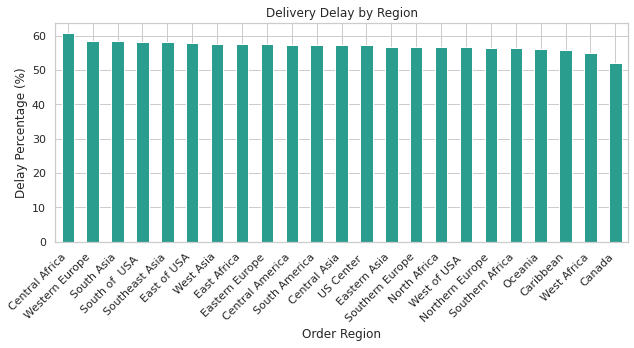

In [58]:
plt.figure(figsize=(9, 5))

region_delay.plot(
    kind='bar',
    color=main_color
)

plt.title('Delivery Delay by Region')
plt.xlabel('Order Region')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.2 Delivery Delay by Customer Segment

The delay percentage is compared across customer segments to identify differences in delivery performance.

In [59]:
segment_delay = df.groupby('Customer Segment')['Is_Delayed'].mean() * 100
segment_delay = segment_delay.sort_values(ascending=False)

segment_delay

Customer Segment
Home Office    57.518774
Consumer       57.294875
Corporate      57.111829
Name: Is_Delayed, dtype: float64

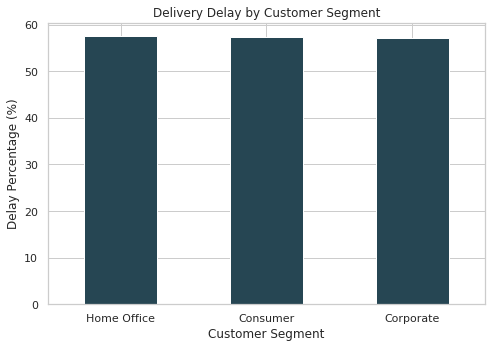

In [60]:
plt.figure(figsize=(7, 5))

segment_delay.plot(
    kind='bar',
    color=dark_color
)

plt.title('Delivery Delay by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.3 Delivery Delay by Shipping Mode

The delay percentage is compared across shipping methods to examine differences in delivery performance.

In [61]:
shipping_delay = df.groupby('Shipping Mode')['Is_Delayed'].mean() * 100
shipping_delay = shipping_delay.sort_values(ascending=False)

shipping_delay

Shipping Mode
First Class       100.000000
Second Class       79.730804
Same Day           47.827873
Standard Class     39.768171
Name: Is_Delayed, dtype: float64

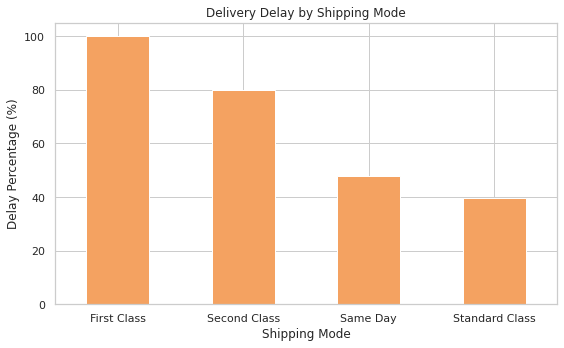

In [62]:
plt.figure(figsize=(8, 5))

shipping_delay.plot(
    kind='bar',
    color=accent_color
)

plt.title('Delivery Delay by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.4 Delivery Delay by Department

The delay percentage is compared across departments to identify differences in delivery performance.

In [63]:
department_delay = df.groupby('Department Name')['Is_Delayed'].mean() * 100
department_delay = department_delay.sort_values(ascending=False)

department_delay

Department Name
Pet Shop              61.382114
Health and Beauty     58.563536
Technology            58.361775
Outdoors              57.856700
Fitness               57.805567
Book Shop             57.530864
Golf                  57.341963
Footwear              57.225473
Fan Shop              57.196273
Apparel               57.163558
Discs Shop            56.712734
Name: Is_Delayed, dtype: float64

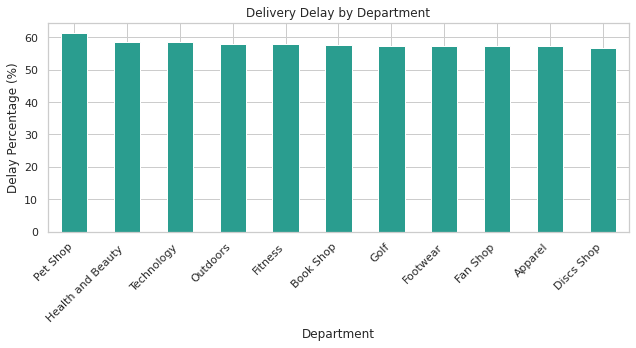

In [64]:
plt.figure(figsize=(9, 5))

department_delay.plot(
    kind='bar',
    color=main_color
)

plt.title('Delivery Delay by Department')
plt.xlabel('Department')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Time-Based Delay Analysis

Delivery delays are analyzed over different time periods to identify recurring patterns.

The analysis covers:

- Delay by month
- Delay by day of the week
- Delay by order hour

### 6.1 Delivery Delay by Month

The monthly delay percentage shows how delivery performance changes across the year.

In [65]:
monthly_delay = df.groupby('order_month')['Is_Delayed'].mean() * 100

monthly_delay

order_month
1     56.866344
2     57.257898
3     57.585275
4     56.715258
5     57.630195
6     57.057930
7     57.028012
8     57.899698
9     57.660275
10    56.850637
11    56.848000
12    57.944218
Name: Is_Delayed, dtype: float64

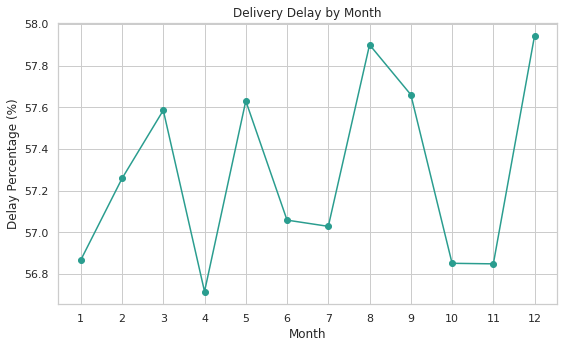

In [66]:
plt.figure(figsize=(8, 5))

monthly_delay.plot(
    marker='o',
    color=main_color
)

plt.title('Delivery Delay by Month')
plt.xlabel('Month')
plt.ylabel('Delay Percentage (%)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### 6.2 Delivery Delay by Day of the Week

The delay percentage is compared across the days of the week to identify differences in delivery performance.

In [67]:
day_delay = df.groupby('order_day')['Is_Delayed'].mean() * 100

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_delay = day_delay.reindex(day_order)

day_delay

order_day
Monday       57.930660
Tuesday      56.603700
Wednesday    57.189198
Thursday     57.238273
Friday       57.527483
Saturday     56.939886
Sunday       57.519464
Name: Is_Delayed, dtype: float64

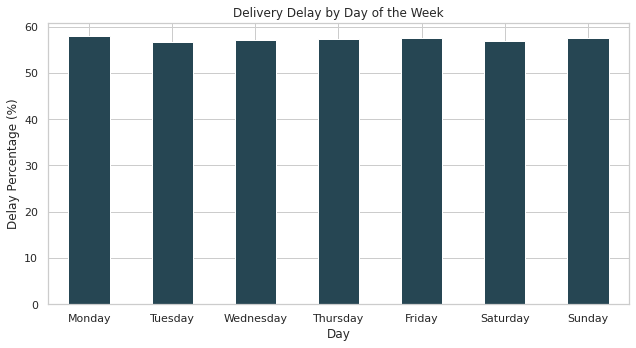

In [68]:
plt.figure(figsize=(9, 5))

day_delay.plot(
    kind='bar',
    color=dark_color
)

plt.title('Delivery Delay by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.3 Delivery Delay by Order Hour

The hourly delay percentage is used to examine whether delivery performance varies based on the time of order placement.

In [69]:
hour_delay = df.groupby('order_hour')['Is_Delayed'].mean() * 100

hour_delay

order_hour
0     53.992095
1     55.338008
2     55.347241
3     53.991935
4     53.880036
5     55.262811
6     52.379642
7     55.121043
8     53.019502
9     54.430380
10    54.891516
11    53.461385
12    62.075875
13    60.556875
14    61.037586
15    60.867238
16    58.805493
17    60.517628
18    60.100876
19    57.625099
20    61.823286
21    59.110570
22    61.242923
23    59.844183
Name: Is_Delayed, dtype: float64

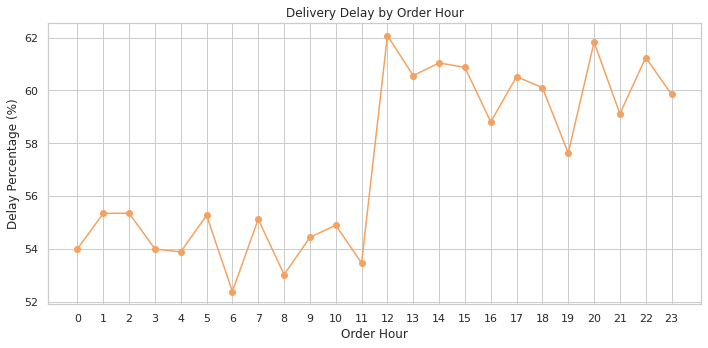

In [70]:
plt.figure(figsize=(10, 5))

hour_delay.plot(
    marker='o',
    color=accent_color
)

plt.title('Delivery Delay by Order Hour')
plt.xlabel('Order Hour')
plt.ylabel('Delay Percentage (%)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### Time-Based Analysis Summary

The monthly, daily, and hourly analysis provides a view of how delivery delays vary over time.

These patterns can be used to identify periods with relatively higher or lower delay rates.

## 7. Delay Driver Analysis

Different order characteristics are compared to identify factors associated with higher delivery delay rates.

The analysis focuses on:

- Shipping Mode
- Customer Segment
- Department
- Order Type
- Order Status

### 7.1 Shipping Mode

The average delay rate is compared across shipping methods.

In [71]:
shipping_delay = df.groupby('Shipping Mode')['Is_Delayed'].mean() * 100
shipping_delay = shipping_delay.sort_values(ascending=False)

shipping_delay

Shipping Mode
First Class       100.000000
Second Class       79.730804
Same Day           47.827873
Standard Class     39.768171
Name: Is_Delayed, dtype: float64

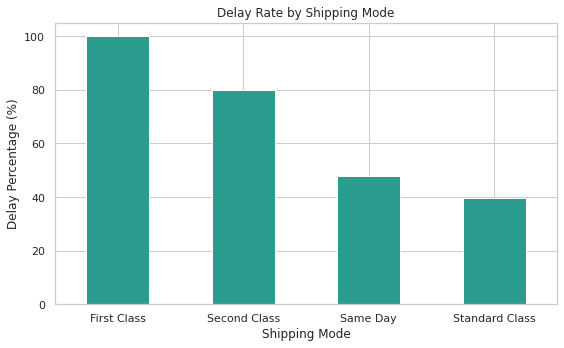

In [72]:
plt.figure(figsize=(8, 5))

shipping_delay.plot(
    kind='bar',
    color=main_color
)

plt.title('Delay Rate by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.2 Customer Segment

The delay rate is compared across customer segments.

In [73]:
segment_delay = df.groupby('Customer Segment')['Is_Delayed'].mean() * 100
segment_delay = segment_delay.sort_values(ascending=False)

segment_delay

Customer Segment
Home Office    57.518774
Consumer       57.294875
Corporate      57.111829
Name: Is_Delayed, dtype: float64

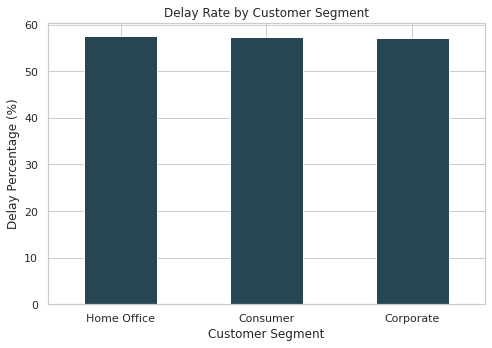

In [74]:
plt.figure(figsize=(7, 5))

segment_delay.plot(
    kind='bar',
    color=dark_color
)

plt.title('Delay Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 8.3 Department

The delay rate is compared across departments to identify differences in delivery performance.

In [75]:
department_delay = df.groupby('Department Name')['Is_Delayed'].mean() * 100
department_delay = department_delay.sort_values(ascending=False)

department_delay

Department Name
Pet Shop              61.382114
Health and Beauty     58.563536
Technology            58.361775
Outdoors              57.856700
Fitness               57.805567
Book Shop             57.530864
Golf                  57.341963
Footwear              57.225473
Fan Shop              57.196273
Apparel               57.163558
Discs Shop            56.712734
Name: Is_Delayed, dtype: float64

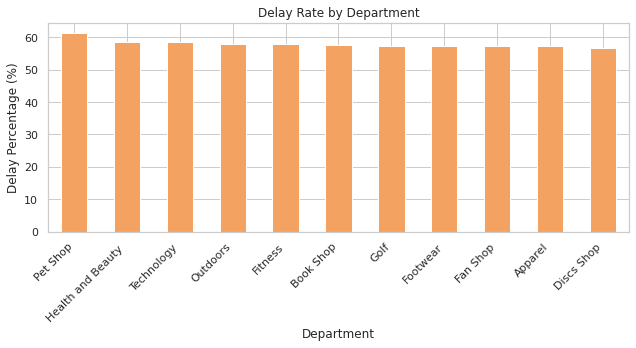

In [76]:
plt.figure(figsize=(9, 5))

department_delay.plot(
    kind='bar',
    color=accent_color
)

plt.title('Delay Rate by Department')
plt.xlabel('Department')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7.4 Order Type

The delay rate is compared across different order types.

In [77]:
type_delay = df.groupby('Type')['Is_Delayed'].mean() * 100
type_delay = type_delay.sort_values(ascending=False)

type_delay

Type
PAYMENT     57.529059
TRANSFER    57.410340
DEBIT       57.217692
CASH        56.632341
Name: Is_Delayed, dtype: float64

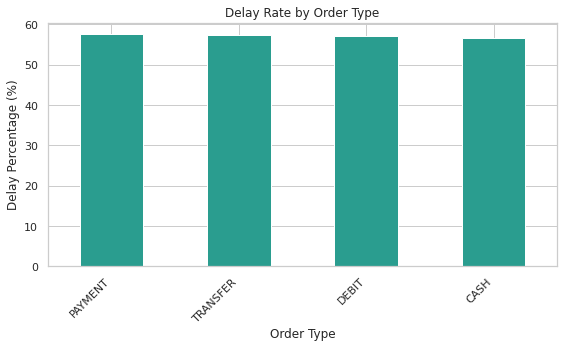

In [78]:
plt.figure(figsize=(8, 5))

type_delay.plot(
    kind='bar',
    color=main_color
)

plt.title('Delay Rate by Order Type')
plt.xlabel('Order Type')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7.5 Order Status

The delay rate is compared across order statuses to examine differences in delivery performance.

In [80]:
status_delay = df.groupby('Order Status')['Is_Delayed'].mean() * 100
status_delay = status_delay.sort_values(ascending=False)

status_delay

Order Status
PENDING            57.902803
PENDING_PAYMENT    57.546696
COMPLETE           57.486006
PAYMENT_REVIEW     57.157950
PROCESSING         57.086111
CANCELED           57.069339
SUSPECTED_FRAUD    57.016248
CLOSED             56.632341
ON_HOLD            55.589555
Name: Is_Delayed, dtype: float64

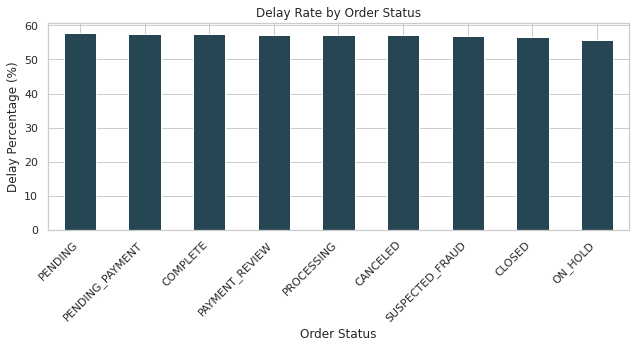

In [81]:
plt.figure(figsize=(9, 5))

status_delay.plot(
    kind='bar',
    color=dark_color
)

plt.title('Delay Rate by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Delay Driver Summary

The analysis shows how delivery delay rates vary across different order characteristics.

The categories with higher delay rates can be examined further when interpreting delivery performance and preparing the machine learning model.

## 8. Financial Performance Analysis

Delivery performance is compared with financial performance to examine whether delayed orders differ in terms of sales and benefit per order.

The analysis focuses on:

- Sales per customer
- Benefit per order
- Delayed and non-delayed orders

In [82]:
financial_analysis = df.groupby('Is_Delayed')[
    ['Sales per customer', 'Benefit per order']
].mean()

financial_analysis

,Sales per customer,Benefit per order
Is_Delayed,,
False,183.672509,22.496873
True,182.686287,21.585751


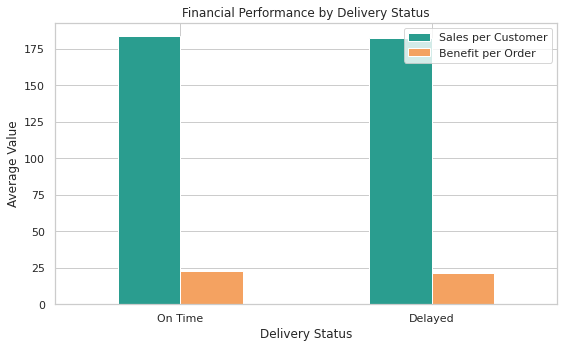

In [83]:
financial_analysis.plot(
    kind='bar',
    figsize=(8, 5),
    color=[main_color, accent_color]
)

plt.title('Financial Performance by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Value')
plt.xticks([0, 1], ['On Time', 'Delayed'], rotation=0)
plt.legend(['Sales per Customer', 'Benefit per Order'])
plt.tight_layout()
plt.show()

### Financial Analysis Summary

The financial analysis compares average sales and benefit values between delayed and non-delayed orders.

Differences between the two groups indicate whether delivery performance is associated with differences in financial performance.

## 9. Machine Learning

Machine learning is used to predict whether an order is at risk of late delivery.

The target variable is **Late_delivery_risk**:

- **0** = No late delivery risk
- **1** = Late delivery risk

Several classification models will be trained and compared using the same training and test data.

### 9.1 Select Features

Relevant order, customer, shipping, and time-related variables are selected as input features.

The target variable is kept separate from the input features.

In [37]:
X = df[
    [
        'Type',
        'Days for shipment (scheduled)',
        'Category Name',
        'Customer Segment',
        'Department Name',
        'Order Region',
        'Shipping Mode',
        'order_month',
        'order_hour'
    ]
]

y = df['Late_delivery_risk']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (180519, 9)
Target: (180519,)


### 9.2 Target Distribution

The distribution of the target classes is checked before training the models.

In [38]:
print(y.value_counts())

1    98977
0    81542
Name: Late_delivery_risk, dtype: int64


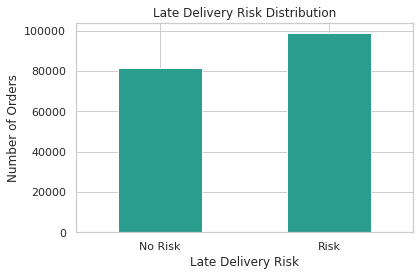

In [39]:
plt.figure(figsize=(6, 4))

y.value_counts().sort_index().plot(
    kind='bar',
    color=main_color
)

plt.title('Late Delivery Risk Distribution')
plt.xlabel('Late Delivery Risk')
plt.ylabel('Number of Orders')
plt.xticks([0, 1], ['No Risk', 'Risk'], rotation=0)
plt.tight_layout()
plt.show()

### 9.3 Convert Categorical Data

Machine learning models require numerical input.

Categorical variables are converted into numerical values using frequency encoding. This replaces each category with the proportion of records belonging to that category.

In [40]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape)

Features after encoding: (180519, 92)


### 9.4 Train-Test Split

The dataset is divided into training and testing sets.

- **80%** of the data is used for training.
- **20%** is used for testing.
- Stratification keeps the target class proportions similar in both sets.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (144415, 92)
Testing data: (36104, 92)


### 9.5 Model Training

Three classification models are used for comparison:

- Logistic Regression
- Decision Tree
- Random Forest

The models are evaluated using the same test dataset.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [43]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [44]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [45]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## 10. Model Evaluation

The three machine learning models are evaluated using common classification metrics.

The main metrics are:

- **Accuracy**: Overall percentage of correct predictions
- **Precision**: Percentage of predicted late deliveries that were actually late
- **Recall**: Percentage of actual late deliveries correctly identified
- **F1 Score**: Balance between precision and recall

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Model Performance

The predictions from each model are compared using the same evaluation metrics.

In [47]:
results = []

models = {
    'Logistic Regression': log_pred,
    'Decision Tree': tree_pred,
    'Random Forest': rf_pred
}

for name, prediction in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, prediction),
        'Precision': precision_score(y_test, prediction),
        'Recall': recall_score(y_test, prediction),
        'F1 Score': f1_score(y_test, prediction)
    })

results_df = pd.DataFrame(results)

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.710,0.853,0.568,0.682
1,Decision Tree,0.745,0.780,0.746,0.763
2,Random Forest,0.717,0.748,0.731,0.739


### Model Comparison

The comparison table shows the performance of the three models on the test data.

The model with the strongest overall evaluation metrics can be selected for further optimization.

<Figure size 648x360 with 0 Axes>

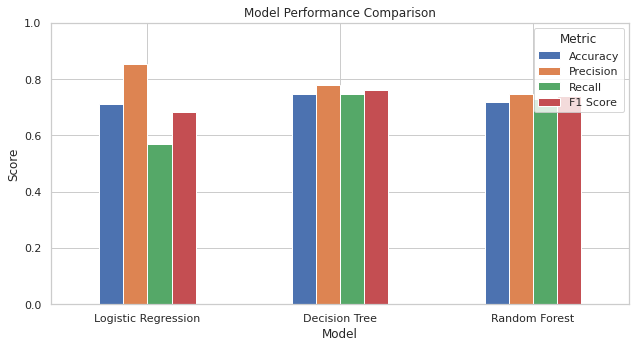

In [48]:
plt.figure(figsize=(9, 5))

results_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## 11. Select and Optimize the Best Model

The model comparison results are used to select the best-performing model.

The F1 Score is used as the main selection metric because it considers both precision and recall.

The selected model is then tested with a few different settings to improve its performance.

In [49]:
best_model_name = results_df.loc[
    results_df['F1 Score'].idxmax(),
    'Model'
]

best_score = results_df['F1 Score'].max()

print("Best Model:", best_model_name)
print("F1 Score:", round(best_score, 3))

Best Model: Decision Tree
F1 Score: 0.763


### Model Selection

The model with the highest F1 Score is selected for further optimization.

In [50]:
if best_model_name == 'Logistic Regression':
    best_model = LogisticRegression(max_iter=1000)

elif best_model_name == 'Decision Tree':
    best_model = DecisionTreeClassifier(random_state=42)

else:
    best_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

best_model.fit(X_train, y_train)

best_prediction = best_model.predict(X_test)

### Final Model Performance

The selected model is evaluated using accuracy, precision, recall, and F1 Score.

In [51]:
print("Model:", best_model_name)
print("Accuracy:", round(accuracy_score(y_test, best_prediction), 3))
print("Precision:", round(precision_score(y_test, best_prediction), 3))
print("Recall:", round(recall_score(y_test, best_prediction), 3))
print("F1 Score:", round(f1_score(y_test, best_prediction), 3))

Model: Decision Tree
Accuracy: 0.745
Precision: 0.78
Recall: 0.746
F1 Score: 0.763


### Classification Report

The classification report provides detailed performance results for each target class.

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, best_prediction))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73     16308
           1       0.78      0.75      0.76     19796

    accuracy                           0.75     36104
   macro avg       0.74      0.75      0.74     36104
weighted avg       0.75      0.75      0.75     36104



## 12. Final Results and Business Recommendations

The analysis provides an overview of delivery performance and the factors associated with late deliveries.

The main findings are based on:

- Overall delivery delay rate
- Regional delivery performance
- Customer segment and shipping mode analysis
- Department and order type analysis
- Time-based delay patterns
- Machine learning model performance

In [53]:
print("Total Orders:", total_orders)
print("Delayed Orders:", delayed_orders)
print("Overall Delay Rate:", round(delayed_orders / total_orders * 100, 2), "%")

print("\nBest Machine Learning Model:", best_model_name)
print("Best F1 Score:", round(best_score, 3))

Total Orders: 180519
Delayed Orders: 103400
Overall Delay Rate: 57.28 %

Best Machine Learning Model: Decision Tree
Best F1 Score: 0.763


## Key Findings

The following points summarize the main patterns identified during the analysis.

In [54]:
print("Highest Delay Region:")
print(region_delay.idxmax(), "-", round(region_delay.max(), 2), "%")

print("\nHighest Delay Shipping Mode:")
print(shipping_delay.idxmax(), "-", round(shipping_delay.max(), 2), "%")

print("\nHighest Delay Customer Segment:")
print(segment_delay.idxmax(), "-", round(segment_delay.max(), 2), "%")

print("\nHighest Delay Department:")
print(department_delay.idxmax(), "-", round(department_delay.max(), 2), "%")

Highest Delay Region:
Central Africa - 60.7 %

Highest Delay Shipping Mode:
First Class - 100.0 %

Highest Delay Customer Segment:
Home Office - 57.52 %

Highest Delay Department:
Pet Shop - 61.38 %


## Business Recommendations

The analysis can support the following areas of supply chain improvement:

1. **Focus on high-delay regions**  
   Regions with higher delay rates can be reviewed to identify operational or transportation issues.

2. **Review shipping performance**  
   Shipping methods with higher delay rates can be examined to understand differences in delivery performance.

3. **Monitor high-delay departments**  
   Departments with higher delay rates can be investigated for possible fulfillment or processing issues.

4. **Monitor time-based patterns**  
   Periods with higher delay rates can be monitored to support better planning and resource allocation.

5. **Use predictive modeling**  
   The selected machine learning model can be used to identify orders with a higher risk of late delivery.

## Conclusion

This analysis examined supply chain delivery performance using order, customer, product, shipping, and time-related information.

The exploratory analysis identified differences in delivery delay rates across regions, customer segments, shipping methods, departments, order types, and time periods.

Machine learning models were also compared to predict late delivery risk. The model with the strongest F1 Score was selected for further evaluation.

Overall, the analysis provides a data-driven view of delivery performance and identifies areas that can be monitored to improve supply chain efficiency.